# NDVI preprocessing baseline

This notebook loads one AOI ingestion run, applies the Phase A preprocessing baseline, and visualizes NDVI before and after preprocessing.


In [9]:
from pathlib import Path
import sys
import matplotlib.pyplot as plt

def find_repo_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / "farmtrust_core").exists() and (candidate / "data").exists():
            return candidate
    raise RuntimeError(f"Could not locate repo root from {start}")

REPO_ROOT = find_repo_root(Path.cwd())
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from farmtrust_core.preprocess.pipeline import build_preprocess_artifacts

RUN_DIR = REPO_ROOT / "data" / "aoi_demo_01"
CSV_PATH = RUN_DIR / "indices_timeseries.csv"
META_PATH = RUN_DIR / "run_metadata.json"

assert CSV_PATH.exists(), f"Missing {CSV_PATH}"
assert META_PATH.exists(), f"Missing {META_PATH}"


In [10]:
import csv
import json

artifacts = build_preprocess_artifacts(CSV_PATH, META_PATH)
metadata = artifacts["metadata"]
raw_rows = artifacts["raw_observations"]
merged_rows = artifacts["merged_observations"]
processed_rows = artifacts["processed_observations"]
quality_metrics = artifacts["quality_metrics"]
PREPROCESS_DIR = REPO_ROOT / "data" / "preprocess" / metadata["aoi_id"]
SMOOTHED_CSV_PATH = PREPROCESS_DIR / "ndvi_smoothed.csv"
QUALITY_JSON_PATH = PREPROCESS_DIR / "quality_metrics.json"

quality_metrics


{'aoi_id': 'aoi_demo_01',
 'total_observation_count': 206,
 'merged_observation_count': 187,
 'usable_observation_count': 177,
 'dropped_observation_count': 10,
 'gap_ratio': 0.24686646729353554,
 'max_gap_days': 24.996967581018517,
 'median_gap_days': 3.006828703703704,
 'smoothing_method': 'rolling_median_3_then_mean_3',
 'usable_valid_fraction_threshold': 0.9,
 'gap_risk': 'high',
 'confidence_penalty': 'high',
 'gap_risk_reason': 'Long or frequent gaps may hide season onset, interruption, or peak timing.',
 'confidence_inputs': {'usable_observation_count': 177,
  'gap_ratio': 0.24686646729353554,
  'max_gap_days': 24.996967581018517}}

In [11]:
assert SMOOTHED_CSV_PATH.exists(), f"Missing {SMOOTHED_CSV_PATH}"
assert QUALITY_JSON_PATH.exists(), f"Missing {QUALITY_JSON_PATH}"

expected_csv_columns = [
    "timestamp",
    "ndvi_raw",
    "ndvi_smoothed",
    "valid_fraction",
    "is_usable",
    "source_row_count",
]
expected_json_keys = [
    "aoi_id",
    "total_observation_count",
    "merged_observation_count",
    "usable_observation_count",
    "dropped_observation_count",
    "gap_ratio",
    "max_gap_days",
    "median_gap_days",
    "smoothing_method",
    "usable_valid_fraction_threshold",
    "gap_risk",
    "confidence_penalty",
    "gap_risk_reason",
    "confidence_inputs",
]

with SMOOTHED_CSV_PATH.open("r", encoding="utf-8", newline="") as handle:
    csv_reader = csv.DictReader(handle)
    csv_columns = list(csv_reader.fieldnames or [])
    smoothed_preview = []
    for _, row in zip(range(5), csv_reader):
        smoothed_preview.append(row)

quality_metrics_file = json.loads(QUALITY_JSON_PATH.read_text(encoding="utf-8"))
json_keys = list(quality_metrics_file.keys())
missing_json_keys = [key for key in expected_json_keys if key not in quality_metrics_file]
unexpected_json_keys = [key for key in quality_metrics_file if key not in expected_json_keys]

assert csv_columns == expected_csv_columns, f"Unexpected CSV columns: {csv_columns}"
assert not missing_json_keys, f"Missing JSON keys: {missing_json_keys}"
assert not unexpected_json_keys, f"Unexpected JSON keys: {unexpected_json_keys}"

{
    "smoothed_csv_columns": csv_columns,
    "quality_json_keys": json_keys,
    "smoothed_preview": smoothed_preview,
}


{'smoothed_csv_columns': ['timestamp',
  'ndvi_raw',
  'ndvi_smoothed',
  'valid_fraction',
  'is_usable',
  'source_row_count'],
 'quality_json_keys': ['aoi_id',
  'confidence_inputs',
  'dropped_observation_count',
  'confidence_penalty',
  'gap_ratio',
  'gap_risk',
  'gap_risk_reason',
  'max_gap_days',
  'median_gap_days',
  'merged_observation_count',
  'smoothing_method',
  'total_observation_count',
  'usable_observation_count',
  'usable_valid_fraction_threshold'],
 'smoothed_preview': [{'timestamp': '2025-08-03T08:37:11.025000+00:00',
   'ndvi_raw': '0.4013343955818197',
   'ndvi_smoothed': '',
   'valid_fraction': '0.7939278864492392',
   'is_usable': 'false',
   'source_row_count': '2'},
  {'timestamp': '2025-08-12T08:35:21.024000+00:00',
   'ndvi_raw': '0.40327078104019165',
   'ndvi_smoothed': '',
   'valid_fraction': '0.5859144807761408',
   'is_usable': 'false',
   'source_row_count': '1'},
  {'timestamp': '2025-08-13T08:36:21.025000+00:00',
   'ndvi_raw': '0.3585989028

In [12]:
duplicate_days = [row for row in merged_rows if row.source_row_count > 1]
summary = {
    "aoi_id": metadata.get("aoi_id"),
    "raw_rows": len(raw_rows),
    "merged_rows": len(merged_rows),
    "days_with_duplicates": len(duplicate_days),
    "usable_rows": sum(1 for row in processed_rows if row.is_usable),
    "gap_risk": quality_metrics["gap_risk"],
    "confidence_penalty": quality_metrics["confidence_penalty"],
    "gap_risk_reason": quality_metrics["gap_risk_reason"],
}
summary


{'aoi_id': 'aoi_demo_01',
 'raw_rows': 206,
 'merged_rows': 187,
 'days_with_duplicates': 19,
 'usable_rows': 177,
 'gap_risk': 'high',
 'confidence_penalty': 'high',
 'gap_risk_reason': 'Long or frequent gaps may hide season onset, interruption, or peak timing.'}

In [13]:
preview = []
for row in processed_rows:
    if row.source_row_count > 1:
        preview.append(
            (
                row.timestamp.isoformat(),
                row.ndvi_raw,
                row.valid_fraction,
                row.source_row_count,
                row.is_usable,
            )
        )
preview[:10]


[('2025-04-17T08:26:09.024000+00:00',
  0.3509010239279554,
  0.9999640688441875,
  2,
  True),
 ('2025-04-27T08:25:59.024000+00:00',
  0.2968988515901108,
  0.974580684513778,
  2,
  True),
 ('2025-06-06T08:25:59.024000+00:00',
  0.177016855532078,
  0.9962057233425544,
  2,
  True),
 ('2025-06-16T08:25:59.024000+00:00',
  0.2219592246952258,
  0.9998922142805204,
  2,
  True),
 ('2025-06-26T08:25:59.024000+00:00',
  0.3100000545556547,
  0.9998203700493208,
  2,
  True),
 ('2025-07-06T08:26:09.024000+00:00', 0.4039957970380783, 1.0, 2, True),
 ('2025-07-16T08:26:09.024000+00:00', 0.4268614798784256, 1.0, 2, True),
 ('2025-08-15T08:25:59.024000+00:00', 0.33998656272888184, 1.0, 2, True),
 ('2025-08-25T08:25:59.024000+00:00',
  0.2720591774963581,
  0.9988153163874774,
  2,
  True),
 ('2025-09-14T08:25:59.024000+00:00',
  0.1436843354576312,
  0.978877078504552,
  2,
  True)]

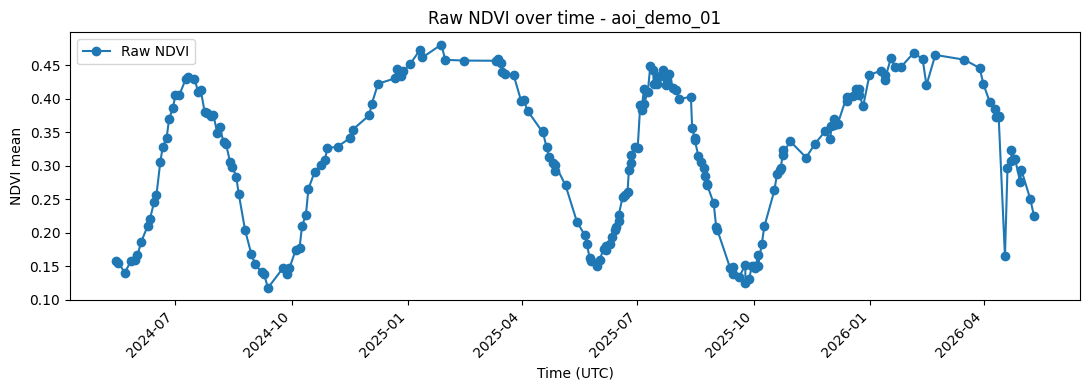

In [14]:
plt.figure(figsize=(11, 4))
plt.plot(
    [row.timestamp for row in raw_rows],
    [row.ndvi_raw for row in raw_rows],
    marker="o",
    linestyle="-",
    label="Raw NDVI",
)
plt.title(f"Raw NDVI over time - {metadata.get('aoi_id', 'unknown_aoi')}")
plt.xlabel("Time (UTC)")
plt.ylabel("NDVI mean")
plt.xticks(rotation=45, ha="right")
plt.legend()
plt.tight_layout()
plt.show()


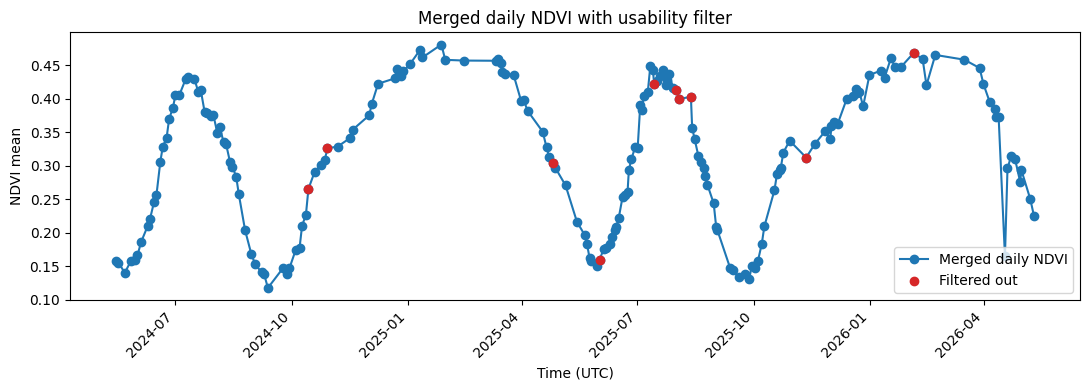

In [15]:
usable_rows = [row for row in processed_rows if row.is_usable]
non_usable_rows = [row for row in processed_rows if not row.is_usable]

plt.figure(figsize=(11, 4))
plt.plot(
    [row.timestamp for row in processed_rows],
    [row.ndvi_raw for row in processed_rows],
    marker="o",
    linestyle="-",
    label="Merged daily NDVI",
)
if non_usable_rows:
    plt.scatter(
        [row.timestamp for row in non_usable_rows],
        [row.ndvi_raw for row in non_usable_rows],
        color="tab:red",
        label="Filtered out",
        zorder=3,
    )
plt.title("Merged daily NDVI with usability filter")
plt.xlabel("Time (UTC)")
plt.ylabel("NDVI mean")
plt.xticks(rotation=45, ha="right")
plt.legend()
plt.tight_layout()
plt.show()


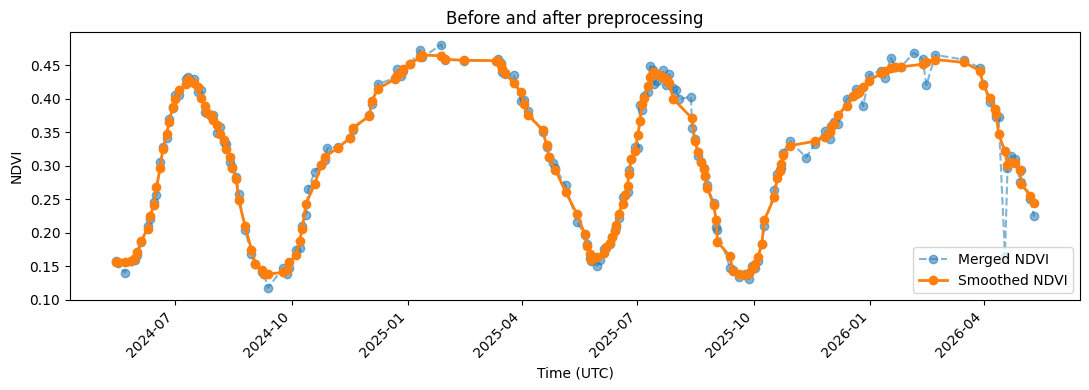

In [16]:
plt.figure(figsize=(11, 4))
plt.plot(
    [row.timestamp for row in processed_rows],
    [row.ndvi_raw for row in processed_rows],
    marker="o",
    linestyle="--",
    alpha=0.55,
    label="Merged NDVI",
)
plt.plot(
    [row.timestamp for row in usable_rows],
    [row.ndvi_smoothed for row in usable_rows],
    marker="o",
    linestyle="-",
    linewidth=2,
    label="Smoothed NDVI",
)
plt.title("Before and after preprocessing")
plt.xlabel("Time (UTC)")
plt.ylabel("NDVI")
plt.xticks(rotation=45, ha="right")
plt.legend()
plt.tight_layout()
plt.show()
